In [1]:
import sys 
import os 

sys.path.append(os.path.join('..', '..'))

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt 
import seaborn as sns

In [3]:
data_dir = Path("../../data/base_de_dados_final/")
arquivo = data_dir / "base_feature_engineering.csv"

In [4]:
df = pd.read_csv(arquivo, sep=";", encoding="latin1", dtype=str)

In [5]:
df.head()

,ATENDIMENTO_BAIRRO_NOME,FLAG_EQUIPAMENTO_URBANO,FLAG_FLAGRANTE,NATUREZA1_DEFESA_CIVIL,NATUREZA2_DEFESA_CIVIL,NATUREZA3_DEFESA_CIVIL,NATUREZA4_DEFESA_CIVIL,NATUREZA5_DEFESA_CIVIL,OCORRENCIA_DIA_SEMANA,OCORRENCIA_MES,...,OUTROS,log_rendimento,log_pop,rendimento_medio_responsavel_sm_estimado_norm,pct_alfabetizacao_15mais_estimado_norm,pct_sem_banheiro_sanitario_estimado_norm,pct_esgotamento_precario_estimado_norm,pct_sem_rede_geral_agua_estimado_norm,pct_lixo_destino_inadequado_estimado_norm,IQV_final
0,cidade industrial,0,0,0,0,0,0,0,5,1,...,0,1.2725655957915476,12.054569291774312,0.10430247718383312,0.5860284605433375,0.8524590163934427,0.9580992133568791,0.9939548202354438,0.9832635983263598,54.575836660173394
1,fazendinha,1,0,0,0,0,0,0,5,1,...,0,1.4445632692438664,10.249025712063943,0.1479791395045633,0.693402328589909,0.9344262295081966,0.981377428158613,0.9977728285077951,0.9916317991631799,60.589451314297285
2,uberaba,0,0,0,0,0,0,0,5,1,...,1,1.5933085305042167,11.181751169442313,0.19230769230769235,0.693402328589909,0.819672131147541,0.9049606678439557,0.960229080496341,0.9832635983263598,60.09137967837168
3,sitio cercado,0,0,0,0,0,0,0,5,1,...,1,1.2412685890696329,11.664899491892095,0.0971316818774446,0.5795601552393275,0.8360655737704918,0.9849092952319795,0.9910913140311803,0.99581589958159,54.28874525901941
4,tatuquara,1,0,0,0,0,0,0,5,1,...,0,1.1085626195212777,10.856862100640145,0.06910039113428944,0.3984476067270371,0.721311475409836,0.8515010435061807,0.9882278078269169,0.9163179916317991,44.56291924850032


In [6]:
df.columns

Index(['ATENDIMENTO_BAIRRO_NOME', 'FLAG_EQUIPAMENTO_URBANO', 'FLAG_FLAGRANTE',
       'NATUREZA1_DEFESA_CIVIL', 'NATUREZA2_DEFESA_CIVIL',
       'NATUREZA3_DEFESA_CIVIL', 'NATUREZA4_DEFESA_CIVIL',
       'NATUREZA5_DEFESA_CIVIL', 'OCORRENCIA_DIA_SEMANA', 'OCORRENCIA_MES',
       'OCORRENCIA_DIA', 'MADRUGADA', 'MANHA', 'TARDE', 'NOITE',
       'CRIME_VIOLENTO', 'ATENDIMENTO_OPERACIONAL_ASSISTENCIAL',
       'ACIDENTE_TRANSITO', 'CRIME_PATRIMONIAL', 'CRIME_DROGAS_SUBSTANCIAS',
       'CRIME_ORDEM_PUBLICA', 'ano', 'populacao_estimado', 'OUTROS',
       'log_rendimento', 'log_pop',
       'rendimento_medio_responsavel_sm_estimado_norm',
       'pct_alfabetizacao_15mais_estimado_norm',
       'pct_sem_banheiro_sanitario_estimado_norm',
       'pct_esgotamento_precario_estimado_norm',
       'pct_sem_rede_geral_agua_estimado_norm',
       'pct_lixo_destino_inadequado_estimado_norm', 'IQV_final'],
      dtype='str')

### Análise da relação entre IQV e tipos de ocorrência criminal 

Nesta etapa, busca-se investigar se existe uma relação linear entre o Índice de Qualidade de Vida (IQV) dos bairros e a incidência de ocorrências relacionadas a:

- `CRIME_VIOLENTO`;
- `CRIME_DROGAS_SUBSTANCAIS`;
- `CRIME_PATRIMONIAL`;
- `CRIME_ORDEM_PUBLICA`

O IQV foi calculado por bairro a partir da média dos indicadores socioeconômicos normalizados, conforme a seguite expressão:

$$
\text{IQV}_{b} = \frac{100}{3}(x_{\text{renda, b}}^{\text{norm}} + x_{\text{alfabetização, b}}^{\text{norm}}) + \frac{100}{12}x_{\text{saneamento, b}}^{\text{norm}}
$$

onde 

$$
x_{\text{sanemanto, b}}^{\text{norm}} = x_{\text{banheiro, b}}^{\text{norm}} + x_{\text{esgotamento, b}}^{\text{norm}} + x_{\text{agua, b}}^{\text{norm}} + x_{\text{lixo, b}}^{\text{norm}}
$$

em que $\text{IQV}_{b}$ representa o índice de qualidade de vida por bairro $b$.
Os indicadores considerados no cálculo do IQV foram:

- `rendimento_medio_responsavel_sm_estimado`;
- `pct_alfabetizacao_15mais_estimado`;
- `pct_sem_banheiro_sanitario_estimado`;
- `pct_sem_rede_geral_agua_estimado`;
- `pct_lixo_destinado_inadequado_estimado`

Todos os indicadores foram normalizados pelo método Min-Max, de modo a permitir sua comparação em uma mesma escala. Para os indicadores positivos, nos quais valores maiores representam melhores condições socioeconômicas, foi utilizada a normaliozação direta. Já para os indicadores negativos, nos quais valores maiores indicam piores condições, foi utilizada a normalização invertida.

### 1. Transformando as colunas em numéricas

In [7]:
cols_int = [
    "FLAG_EQUIPAMENTO_URBANO",
    "FLAG_FLAGRANTE",
    "NATUREZA1_DEFESA_CIVIL",
    "NATUREZA2_DEFESA_CIVIL",
    "NATUREZA3_DEFESA_CIVIL",
    "NATUREZA4_DEFESA_CIVIL",
    "NATUREZA5_DEFESA_CIVIL",
    "OCORRENCIA_MES",
    "OCORRENCIA_DIA",
    "MADRUGADA",
    "MANHA",
    "TARDE",
    "NOITE",
    "CRIME_VIOLENTO",
    "ATENDIMENTO_OPERACIONAL_ASSISTENCIAL",
    "ACIDENTE_TRANSITO",
    "CRIME_PATRIMONIAL",
    "CRIME_DROGAS_SUBSTANCIAS",
    "CRIME_ORDEM_PUBLICA",
    "ano",
    "OUTROS"
]

In [8]:
for col in cols_int:
    df[col] = pd.to_numeric(df[col], errors="coerce").astype("int64")

In [9]:
cols_float = [
    "populacao_estimado",
    "log_pop",
    "log_rendimento",
    "pct_alfabetizacao_15mais_estimado_norm",
    "pct_sem_banheiro_sanitario_estimado_norm",
    "pct_esgotamento_precario_estimado_norm",
    "pct_sem_rede_geral_agua_estimado_norm",
    "pct_lixo_destino_inadequado_estimado_norm",
    "IQV_final"
]

In [10]:
for col in cols_float:
    df[col] = pd.to_numeric(df[col], errors="coerce").astype("float64")

Vamos dropar colunas que não vão participar da análise:

In [11]:
df = df.drop(columns=["FLAG_FLAGRANTE", "FLAG_EQUIPAMENTO_URBANO", "NATUREZA1_DEFESA_CIVIL", "NATUREZA2_DEFESA_CIVIL",
                    "NATUREZA3_DEFESA_CIVIL", "NATUREZA4_DEFESA_CIVIL",
                    "NATUREZA5_DEFESA_CIVIL", "log_rendimento",
                    "rendimento_medio_responsavel_sm_estimado_norm", 
                    "pct_alfabetizacao_15mais_estimado_norm",
                    "pct_sem_banheiro_sanitario_estimado_norm",
                    "pct_esgotamento_precario_estimado_norm",
                    "pct_sem_rede_geral_agua_estimado_norm",
                    "pct_lixo_destino_inadequado_estimado_norm"],
                    )

In [12]:
df = df.rename(columns={
    'ATENDIMENTO_BAIRRO_NOME': 'bairro',
    'OCORRENCIA_MES': 'mes',
    'IQV_final': 'IQV'
})

Além da análise contínua do IQV, os bairros também serão classificados em três grupos, com base nos quartis da distribuição do índice. Essa divisão permite uma leitura mais geral dos resultados, evitando a necessidade de analisar separadamente todos os bairros em todos os anos.

A classificação adotada foi:

1. Baixo IQV: bairros com $\text{IQV}_{b} \leq p_{0.25}$;
2. Médio IQV: bairros com $p_{0.25} < \text{IQV}_{b} < p_{0.75}$;
3. Alto IQV: bairros com $\text{IQV}_{b} \geq p_{0.75}$

In [13]:
p25 = df["IQV"].quantile(0.25)
p75 = df["IQV"].quantile(0.75)

In [14]:
df["classe_IQV"] = np.select(
    [
        df["IQV"] < p25,
        df["IQV"] > p75
    ],
    [
        "Baixo IQV",
        "Alto IQV"
    ],
    default="Médio IQV"
)

In [15]:
df[["bairro", "IQV", "classe_IQV"]].drop_duplicates().sort_values("IQV")

,bairro,IQV,classe_IQV
168,caximba,14.512563,Baixo IQV
25849,caximba,16.242854,Baixo IQV
47166,caximba,17.490152,Baixo IQV
68760,caximba,18.412726,Baixo IQV
90348,caximba,19.055363,Baixo IQV
...,...,...,...
88219,batel,96.915989,Alto IQV
68687,batel,97.600733,Alto IQV
49029,batel,98.282826,Alto IQV
24960,batel,98.986311,Alto IQV


In [16]:
df.columns

Index(['bairro', 'OCORRENCIA_DIA_SEMANA', 'mes', 'OCORRENCIA_DIA', 'MADRUGADA',
       'MANHA', 'TARDE', 'NOITE', 'CRIME_VIOLENTO',
       'ATENDIMENTO_OPERACIONAL_ASSISTENCIAL', 'ACIDENTE_TRANSITO',
       'CRIME_PATRIMONIAL', 'CRIME_DROGAS_SUBSTANCIAS', 'CRIME_ORDEM_PUBLICA',
       'ano', 'populacao_estimado', 'OUTROS', 'log_pop', 'IQV', 'classe_IQV'],
      dtype='str')

A relação linear entre o IQV e cada categoria de ocorrência pode ser representada pela equação:

$$
y_{b, t, C} = \beta_{0} + \beta_{1} \times \text{IQV}_{b, t} +  \gamma_t + \varepsilon_{b, t}
$$

onde:

- $b$ é o bairro;
- $t$ é o ano;
- $C$ é a categoria do crime;
- $\gamma_t$ representa efeitos do ano, como mudanças gerais na cidade.

Nesse caso, $C$ representa uma das seguintes categorias analisadas.

In [17]:
categorias = [
    "CRIME_VIOLENTO",
    "CRIME_DROGAS_SUBSTANCIAS",
    "CRIME_PATRIMONIAL",
    "CRIME_ORDEM_PUBLICA"
]

In [18]:
df_bairro_ano = (
    df
    .groupby(["bairro", "ano"])
    .agg({
        "populacao_estimado": "first",
        "IQV": "first",
        "CRIME_VIOLENTO": "sum",
        "CRIME_DROGAS_SUBSTANCIAS": "sum",
        "CRIME_PATRIMONIAL": "sum",
        "CRIME_ORDEM_PUBLICA": "sum"
    })
    .reset_index()
)

In [19]:
for cat in categorias:
    df_bairro_ano[f"{cat}_10k"] = (
        df_bairro_ano[cat] / df_bairro_ano["populacao_estimado"]
    ) * 10_000

In [20]:
modelos = {}

for cat in categorias:
    y = f"{cat}_10k"

    modelo = smf.ols(
        formula=f"{y} ~ IQV",
        data=df_bairro_ano
    ).fit()

    modelos[cat] = modelo 

    print(f"f\nModelo para {cat}")
    print(modelo.summary())

f
Modelo para CRIME_VIOLENTO
                            OLS Regression Results                            
Dep. Variable:     CRIME_VIOLENTO_10k   R-squared:                       0.011
Model:                            OLS   Adj. R-squared:                  0.010
Method:                 Least Squares   F-statistic:                     14.03
Date:                Sat, 23 May 2026   Prob (F-statistic):           0.000188
Time:                        15:35:42   Log-Likelihood:                -6131.9
No. Observations:                1269   AIC:                         1.227e+04
Df Residuals:                    1267   BIC:                         1.228e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.4407  

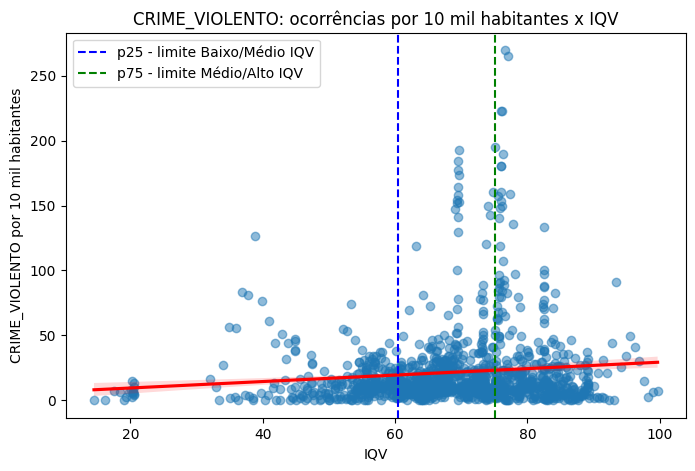

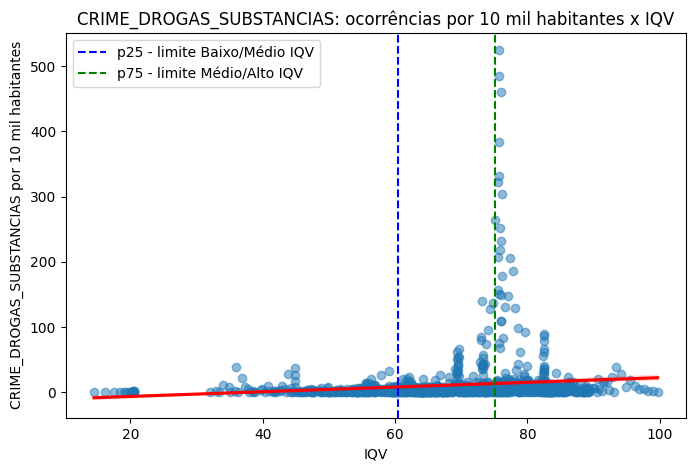

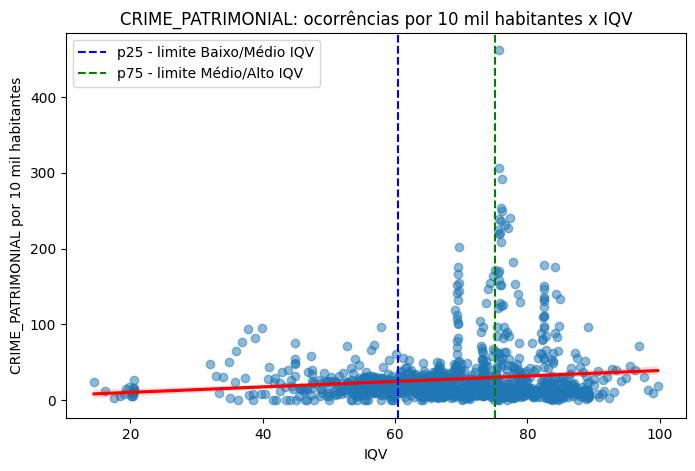

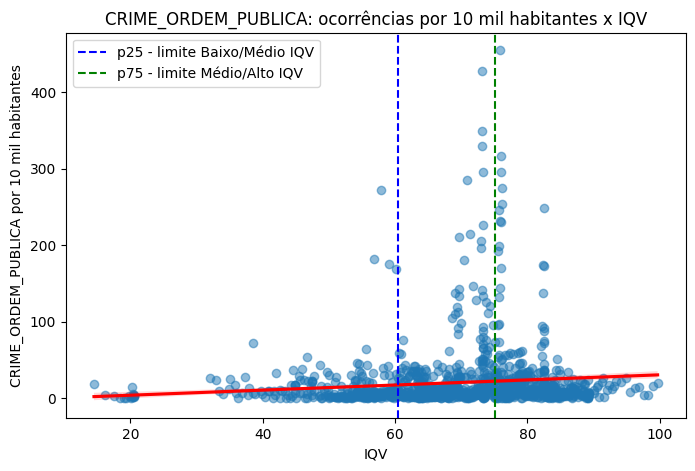

In [21]:
for cat in categorias:
    y = f"{cat}_10k"

    plt.figure(figsize=(8, 5))

    sns.regplot(
        data=df_bairro_ano,
        x="IQV",
        y=y,
        scatter_kws={"alpha": 0.5},
        line_kws={"color": "red"}
    )

    plt.axvline(p25, color="blue", linestyle="--", label="p25 - limite Baixo/Médio IQV")
    plt.axvline(p75, color="green", linestyle="--", label="p75 - limite Médio/Alto IQV")

    plt.title(f"{cat}: ocorrências por 10 mil habitantes x IQV")
    plt.xlabel("IQV")
    plt.ylabel(f"{cat} por 10 mil habitantes")
    plt.legend()
    plt.show()

In [25]:
df_bairro_ano["CRIMES_ANALISADOS_TOTAL"] = df_bairro_ano[categorias].sum(axis=1)

df_bairro_ano["CRIMES_ANALISADOS_10k"] = (
      df_bairro_ano["CRIMES_ANALISADOS_TOTAL"] /
      df_bairro_ano["populacao_estimado"]
) * 10_000

modelo_total = smf.ols(
      formula="CRIMES_ANALISADOS_10k ~ IQV",
      data=df_bairro_ano
  ).fit()

print(modelo_total.summary())


                              OLS Regression Results                             
Dep. Variable:     CRIMES_ANALISADOS_10k   R-squared:                       0.018
Model:                               OLS   Adj. R-squared:                  0.017
Method:                    Least Squares   F-statistic:                     22.62
Date:                   Sat, 23 May 2026   Prob (F-statistic):           2.20e-06
Time:                           15:36:39   Log-Likelihood:                -7929.8
No. Observations:                   1269   AIC:                         1.586e+04
Df Residuals:                       1267   BIC:                         1.587e+04
Df Model:                              1                                         
Covariance Type:               nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -8.8833 

In [26]:
modelo_total_ano = smf.ols(
      formula="CRIMES_ANALISADOS_10k ~ IQV + C(ano)",
      data=df_bairro_ano
  ).fit()

print(modelo_total_ano.summary())


                              OLS Regression Results                             
Dep. Variable:     CRIMES_ANALISADOS_10k   R-squared:                       0.029
Model:                               OLS   Adj. R-squared:                  0.016
Method:                    Least Squares   F-statistic:                     2.237
Date:                   Sat, 23 May 2026   Prob (F-statistic):            0.00272
Time:                           15:37:02   Log-Likelihood:                -7922.1
No. Observations:                   1269   AIC:                         1.588e+04
Df Residuals:                       1251   BIC:                         1.597e+04
Df Model:                             17                                         
Covariance Type:               nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept     

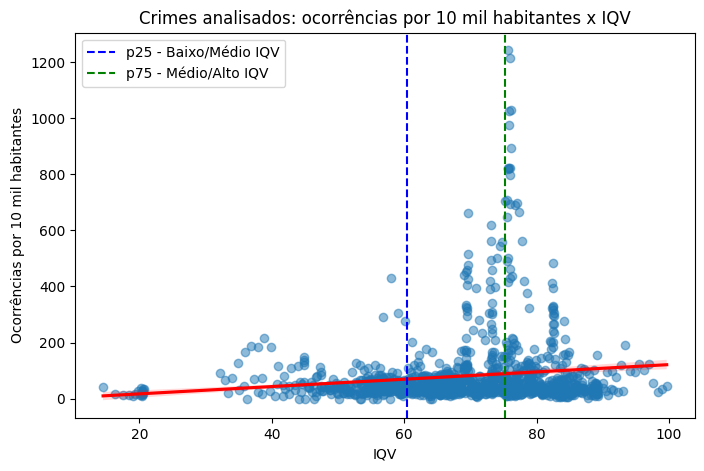

In [27]:
plt.figure(figsize=(8, 5))

sns.regplot(
      data=df_bairro_ano,
      x="IQV",
      y="CRIMES_ANALISADOS_10k",
      scatter_kws={"alpha": 0.5},
      line_kws={"color": "red"}
)

plt.axvline(p25, color="blue", linestyle="--", label="p25 - Baixo/Médio IQV")
plt.axvline(p75, color="green", linestyle="--", label="p75 - Médio/Alto IQV")

plt.title("Crimes analisados: ocorrências por 10 mil habitantes x IQV")
plt.xlabel("IQV")
plt.ylabel("Ocorrências por 10 mil habitantes")
plt.legend()
plt.show()